# Analyze Alpha Diversity

This notebook calculates and compares alpha diversity between the Burkina Faso (BF) and European (EU) populations using multiple richness and diversity metrics.

In [39]:
suppressPackageStartupMessages({

    ########### main libraries ###########
    library(SummarizedExperiment)
    library(TreeSummarizedExperiment)
    library(mia)
    library(miaViz) # mia visualizatioon
    library(tidySingleCellExperiment)
    library(ape) # reads trees
    ########### data manipulation tools ###########
    library(tidyverse)
    library(tibble)
    library(scales)
    ########### visualization libraries ###########   
    library(sechm) # Heatmap library
    library(ggpubr)
    library(pheatmap)
    library(readr)
    library(RColorBrewer)
    library(colorspace)
    library(cowplot)
    library(grid)
    library(patchwork)
    library(gridExtra)
    library(ggrepel)
    library(ggpubr)
    library(ggthemes)
    library(RColorBrewer)
    library(patchwork)
    library(cowplot)
    library(scater)

    library(knitr)
    
    ########### resource management tools ###########
    # library(tictoc)

    ################ notes ####################
    ### loaded by tidyverse
    # library(ggplot2)
    # library(tidyr)
    # library(dplyr)
    # library(readr)
    # library(stringr)
})


warnLevel <- getOption('warn')
options(warn = -1)



### Arguments Piped in with R script Conversion

In [2]:
args <- commandArgs(trailingOnly = TRUE)
if (length(args) >= 2) {
    PROJECT_NAME <- args[1]
    PROJECT_DIR  <- normalizePath(args[2])
} else {
    # defaults for notebook 
    PROJECT_NAME <- "ERP000133"
    PROJECT_DIR  <- normalizePath("..")
}

### Input File Paths (not piped in if R script)

In [3]:
TAXA_DIR <- file.path(PROJECT_DIR, "taxonomy_assignment")
tse_rds_file <- file.path(TAXA_DIR, paste0(PROJECT_NAME, ".ASV_with_taxa.TSE.rds"))


ANALYSIS_DIR <- file.path(PROJECT_DIR, "analysis")
ABUND_DIV_DIR <-  file.path(ANALYSIS_DIR, "abund_div")


TREE_DIR <- file.path(PROJECT_DIR, "qiime2_results_exported", "phylo_rooted_tree_export")


In [4]:
tse <- readRDS( file = file.path(ABUND_DIV_DIR, paste0(PROJECT_NAME, ".tse.rds")))
tse_genus <- readRDS( file = file.path(ABUND_DIV_DIR, paste0(PROJECT_NAME, ".tse_genus.rds")))
tse_phylum <- readRDS( file = file.path(ABUND_DIV_DIR, paste0(PROJECT_NAME, ".tse_phylum.rds")))
tree <- read.tree( file = file.path(TREE_DIR, "tree.nwk"))



### Make Output Directory

In [5]:
# make file output directory if it doesn't already exist
ANALYSIS_DIR <- file.path(PROJECT_DIR, "analysis")
ALPHA_DIV_DIR <-  file.path(ANALYSIS_DIR, "alpha_div")
FIG_DIR <- file.path(PROJECT_DIR, "figures")
FIG_ALPHA_DIV_DIR <- file.path(FIG_DIR, "alpha_div")
dir.create(ANALYSIS_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(ALPHA_DIV_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_ALPHA_DIV_DIR, recursive = TRUE, showWarnings = FALSE)

REPORT_TABLE_DIR <- file.path(PROJECT_DIR, "report_tables")
SUMMARY_TABLE_DIR <- file.path(PROJECT_DIR, "summary_tables") # more extensive tables not for the report go here
dir.create(REPORT_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(SUMMARY_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)


QUARTO_PLOT_TABLE_DIR <- file.path(PROJECT_DIR, "quarto_plot_tables")
dir.create(QUARTO_PLOT_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)

### Set Global Parameters

In [6]:
population_levels <- unique(colData(tse)$population_group)
# Dynamically assign colors to values in population_group
population_levels <- unique(colData(tse)$population_group)

population_colors <- setNames(
    grDevices::hcl.colors(
        length(population_levels),
        palette = "Dark 3"
    ),
    population_levels
)

# population_colors

### Map Rooted Tree onto TSE

In [7]:
all(rownames(tse) %in% tree$tip.label)
all(tree$tip.label %in% rownames(tse))

[1] FALSE

[1] FALSE

In [8]:
rowData(tse)

DataFrame with 1402 rows and 8 columns
             Kingdom         Phylum          Class                  Order
         <character>    <character>    <character>            <character>
ASV_1       Bacteria   Bacteroidota    Bacteroidia          Bacteroidales
ASV_2       Bacteria      Bacillota     Clostridia        Oscillospirales
ASV_3       Bacteria Actinomycetota Actinobacteria      Bifidobacteriales
ASV_4       Bacteria      Bacillota     Clostridia         Lachnospirales
ASV_5       Bacteria   Bacteroidota    Bacteroidia          Bacteroidales
...              ...            ...            ...                    ...
ASV_1398    Bacteria      Bacillota     Clostridia     Christensenellales
ASV_1399    Bacteria      Bacillota     Clostridia Peptostreptococcales..
ASV_1400    Bacteria      Bacillota     Clostridia         Lachnospirales
ASV_1401    Bacteria      Bacillota        Bacilli      Acholeplasmatales
ASV_1402    Bacteria      Bacillota     Clostridia         Lachnospirales

In [9]:
# map the ASV labels onto the tree
asv_map <- setNames(
    rownames(tse),
    rowData(tse)$original_ASV_id
)
# all(tree$tip.label %in% names(asv_map))
tree$tip.label <- asv_map[tree$tip.label]

# anyNA(tree$tip.label)
# anyDuplicated(tree$tip.label)

In [10]:
rowTree(tse) <- tree
rowTree(tse)


Phylogenetic tree with 1402 tips and 1390 internal nodes.

Tip labels:
  ASV_1344, ASV_1335, ASV_88, ASV_167, ASV_243, ASV_82, ...
Node labels:
  , 0.273, 0.179, 0.996, 0.976, 0.732, ...

Rooted; includes branch length(s).

### Estimate Diversity

This step estimates diversity (per sample) in different ways:  
   - __Observed Richness__ - richness just from the number of observed taxa  
        Simply Calculated as Taxa_observed = # ASVs with 1+ read   
   - __Chao1__ - richness estimator. attempts to estimate the true number of taxa in a community, including taxa that were likely to be present but were not detected due to rarity.   
&nbsp;&nbsp;&nbsp;&nbsp;Calculated as Taxa_observed + Singletons_obs / Doubletons_obs  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Second term attempts to capture the amount of richness that was missed  
   - __Shannon__ - alpha diversity measure that combines richness and evenness in one number   
&nbsp;&nbsp;&nbsp;&nbsp;Calculated as H = - Sum_i (p_i * ln(p_i)) , where  p_i = relative abundance of taxon i  
&nbsp;&nbsp;&nbsp;&nbsp;Captures richness and evenness simultaneously   
&nbsp;&nbsp;&nbsp;&nbsp; Shannon can be done non-parametrically, but not here. The original publication used nonparametric Shannon, but since I'm doing ASVs, I'm doing standard, because it ASVs creates a different distribution (also because I'm estimating Chao1, which effectively should do the same thing?)  
   - __Simpson__ - alpha diversity measure (capturing richness & evenness), but more concerned with abundant taxa  
&nbsp;&nbsp;&nbsp;&nbsp;Calculated as D = Sum_i ( p_i ^ 2)  , where  p_i = relative abundance of taxon i  
&nbsp;&nbsp;&nbsp;&nbsp;High D = high dominance / low diversity  
&nbsp;&nbsp;&nbsp;&nbsp;Often people report __Gini-Simpson__, which is just 1 - D , or __inverse Simpson__, which is 1/D  
   - __Faith's phylogenetic diversity (Faith's PD)__ - alpha diversity metric that measures phylogynetic richness, rather than just taxa. It's calculated baased on the lengths of branches for each taxa

Chao1 is basically useless here, because there are no singleton ASVs in the dataset. DADA2 probably pruned anything that would have gotten there. So the value of Chao1 is no different from just observed richness, since the term Singletons_obs / Doubletons_obs = 0 in every sample

In [11]:
# unagreggated tse
tse <- estimateDiversity(
    tse,
    index = c(
        "observed",
        "chao1",
        "shannon",
        "simpson",
        "gini_simpson",
        "inverse_simpson", 
        "faith"
    )
)

# genus
tse_genus <- estimateDiversity(
    tse_genus,
    index = c(
        "observed",
        "chao1",
        "shannon",
        "simpson",
        "gini_simpson",
        "inverse_simpson", 
        "faith"
    )
)

# phylum
tse_phylum <- estimateDiversity(
    tse_phylum,
    index = c(
        "observed",
        "chao1",
        "shannon",
        "simpson",
        "gini_simpson",
        "inverse_simpson", 
        "faith"
    )
)



In [12]:
# double check for singletons, doubletons
counts <- assay(tse, "counts")

colSums(counts == 1)
colSums(counts == 2)

10BF 10EU 11BF 11EU 12BF 12EU 13BF 13EU 15BF 16BF 17BF 17EU 18EU 19EU  1EU 20EU 
   0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0 
21EU  2BF  2EU  3BF  3EU  4BF  5EU  6BF  6EU  7BF  8BF  8EU  9BF 
   0    0    0    0    0    0    0    0    0    0    0    0    0

10BF 10EU 11BF 11EU 12BF 12EU 13BF 13EU 15BF 16BF 17BF 17EU 18EU 19EU  1EU 20EU 
   1    2    0    1    2    1    1    0    0    0    1    0    0    1    0    1 
21EU  2BF  2EU  3BF  3EU  4BF  5EU  6BF  6EU  7BF  8BF  8EU  9BF 
   1    1    0    1    0    0    1    2    1    2    0    0    0

### Get alpha diversity dataframe

In [13]:
alpha_div_df1 <- colData(tse)[, c(
    "observed",
    "chao1",
    "shannon",
        "simpson",
        "gini_simpson",
        "inverse_simpson", 
    "faith"
)]
as.data.frame(alpha_div_df1)

,observed,chao1,shannon,simpson,gini_simpson,inverse_simpson,faith
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10BF,90,90,2.871182,0.07272873,0.8472253,6.545585,8.818393
10EU,128,128,4.013306,0.23250223,0.9663982,29.760285,10.091941
11BF,55,55,1.934080,0.06017715,0.6978618,3.309744,6.035551
11EU,56,56,2.461631,0.09988552,0.8212239,5.593589,5.734657
12BF,76,76,1.929808,0.03625144,0.6370380,2.755109,8.100489
12EU,87,87,3.451106,0.18409155,0.9375623,16.015965,7.234261
13BF,96,96,3.230823,0.09895835,0.8947369,9.500001,9.288940
13EU,85,85,3.383899,0.18278760,0.9356373,15.536946,7.293917
15BF,39,39,2.038892,0.12019454,0.7866706,4.687587,5.049746


In [14]:
alpha_div_all_df <- as.data.frame(colData(tse))
head(as.data.frame(alpha_div_all_df))

,group,run_id,population_group,age_years,sex,reported_ethnicity,antibiotic_history,delivery_mode,clinical_status,location,⋯,observed_ASVs,prevalent_abundance,observed,chao1,chao1_se,shannon,simpson,gini_simpson,inverse_simpson,faith
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10BF,BF,ERR011058,BF,6,female,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,90,0.03382238,90,90,0,2.871182,0.07272873,0.8472253,6.545585,8.818393
10EU,EU,ERR011059,EU,5,male,caucasian,more than 6 months since last use,natural childbirth,healthy,"Italy:Toscany, Florence",⋯,128,0.13685672,128,128,0,4.013306,0.23250223,0.9663982,29.760285,10.091941
11BF,BF,ERR011060,BF,5,male,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,55,0.01473932,55,55,0,1.934080,0.06017715,0.6978618,3.309744,6.035551
11EU,EU,ERR011061,EU,5,male,caucasian,more than 6 months since last use,natural childbirth,healthy,"Italy:Toscany, Florence",⋯,56,0.37195730,56,56,0,2.461631,0.09988552,0.8212239,5.593589,5.734657
12BF,BF,ERR011062,BF,6,male,black african,none known,natural childbirth,no malnutrition,"Burkina Faso:Boulkiemde province,Boulpon",⋯,76,0.01716191,76,76,0,1.929808,0.03625144,0.6370380,2.755109,8.100489
12EU,EU,ERR011063,EU,6,male,caucasian,more than 6 months since last use,natural childbirth,healthy,"Italy:Toscany, Florence",⋯,87,0.35906331,87,87,0,3.451106,0.18409155,0.9375623,16.015965,7.234261


### Plot diversities

In [15]:
make_alpha_plot <- function(
    tse1,
    metric_col1,
    group_col1,
    pop_colors1,
    title1,
    y_label1,
    ySigPush, baseSize1, titleSize1,
    group_levels1 = c("BF", "EU"),
    test_method1 = "wilcox.test"
) {
    
    alpha_div_df1 <- as.data.frame(colData(tse1))
    
    p_alpha <- ggplot(
        alpha_div_df1,
        aes(
            x = .data[[group_col1]],
            y = .data[[metric_col1]],
            fill = .data[[group_col1]]
        )
    ) +
        geom_violin(
            trim = FALSE,
            alpha = 0.7
        ) +
        geom_jitter(
            width = 0.08,
            size = 3,
            alpha = 0.8
        ) +
        stat_compare_means(
            comparisons = list(group_levels1),
            method = test_method1,
            label = "p.signif",
            fontface = "bold",
            # label.y = max(alpha_div_df1[[metric_col1]]) * 1.32,
            # tried to make this dynamic, didn't work consistently
            label.y = ySigPush,
            
            size = 7
        ) +
        scale_fill_manual(values = pop_colors1) +
        labs(
            title = title1,
            x = NULL,
            y = y_label1
        ) +
        theme_minimal(base_size = baseSize1) +
        theme(
            plot.title = element_text(
                face = "bold",
                size = titleSize1,
                hjust = 0.5
            ),
            axis.text.y = element_text(face = "bold"),
            axis.text.x = element_text(face = "bold"),
            axis.title = element_text(face = "bold"),
            legend.position = "none"
        )
    
    return(p_alpha)
}

In [41]:
titleSizeSet = 18
baseSizeSet = 15


p_div_shannon <- make_alpha_plot(
                    tse1 = tse,
                    metric_col1 = "shannon",
                    group_col1 = "population_group",
                    pop_colors1 = population_colors,
                    title1 = "Shannon",
                    y_label1 = "Shannon diversity",
                    ySigPush = 6, baseSize1 = baseSizeSet, titleSize1 = titleSizeSet
                )




p_div_obs <-  make_alpha_plot(
                        tse1 = tse,
                        metric_col1 = "observed",
                        group_col1 = "population_group",
                        pop_colors1 = population_colors,
                        title1 = "Observed Richness",
                        y_label1 = "Observed ASVs",
                        ySigPush = 250, baseSize1 = baseSizeSet, titleSize1 = titleSizeSet
                    )

p_div_simpson <-  make_alpha_plot(
                    tse1 = tse,
                    metric_col1 = "simpson",
                    group_col1 = "population_group",
                    pop_colors1 = population_colors,
                    title1 = "Simpson",
                    y_label1 = "Simpson diversity",
                    ySigPush = 0.35, baseSize1 = baseSizeSet, titleSize1 = titleSizeSet
                )

p_div_gini_simpson <-  make_alpha_plot(
                    tse1 = tse,
                    metric_col1 = "gini_simpson",
                    group_col1 = "population_group",
                    pop_colors1 = population_colors,
                    title1 = "Gini-Simpson",
                    y_label1 = "Gini-Simpson diversity",
                    ySigPush = 1.2, baseSize1 = baseSizeSet, titleSize1 = titleSizeSet
                )

p_div_inverse_simpson <-  make_alpha_plot(
                    tse1 = tse,
                    metric_col1 = "inverse_simpson",
                    group_col1 = "population_group",
                    pop_colors1 = population_colors,
                    title1 = "Inverse Simpson",
                    y_label1 = "Gini-Simpson diversity",
                    ySigPush = 65, baseSize1 = baseSizeSet, titleSize1 = titleSizeSet
                )


p_div_chao1 <-  make_alpha_plot(
                    tse1 = tse,
                    metric_col1 = "chao1",
                    group_col1 = "population_group",
                    pop_colors1 = population_colors,
                    title1 = "Chao1",
                    y_label1 = "Chao1 diversity",
                    ySigPush = 255, baseSize1 = baseSizeSet, titleSize1 = titleSizeSet
                )

p_faith <- make_alpha_plot(
    tse1 = tse,
    metric_col1 = "faith",
    group_col1 = "population_group",
    pop_colors1 = population_colors,
    title1 = "Faith's Phylogenetic Diversity",
    y_label1 = "Faith's PD",
                    ySigPush = 17, baseSize1 = baseSizeSet, titleSize1 = titleSizeSet
)
# options(repr.plot.width = 16, repr.plot.height = 12)
# (p_div_shannon + p_div_inverse_simpson + p_div_chao1) / (p_div_gini_simpson + p_div_simpson + p_div_obs + p_faith)

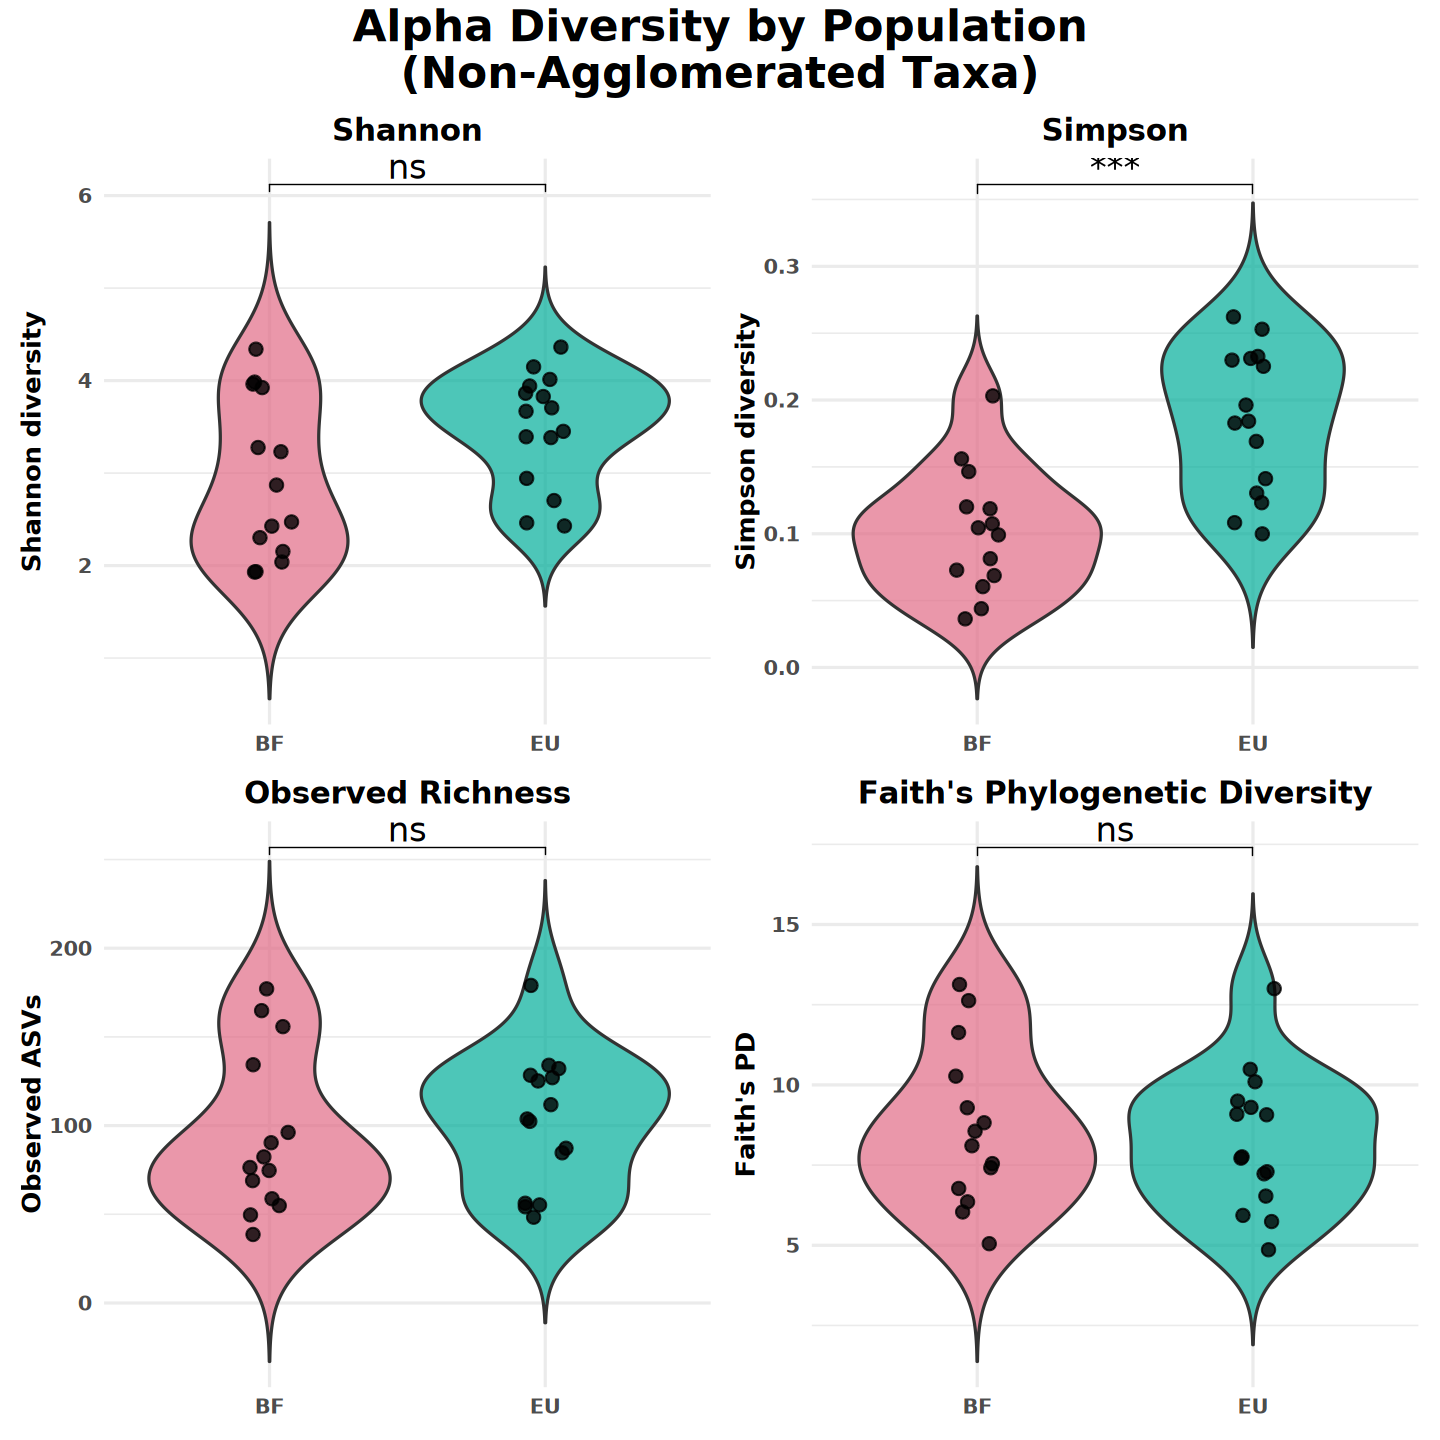

In [31]:
options(repr.plot.width = 12, repr.plot.height = 12)

alpha_combined <-
    p_div_shannon +
    p_div_simpson +
    p_div_obs +
    p_faith +
    plot_layout(ncol = 2) +
    plot_annotation(
        title = "Alpha Diversity by Population\n(Non-Agglomerated Taxa)",
        theme = theme(
            plot.title = element_text(
                face = "bold",
                size = 26,
                hjust = 0.5
            )
        )
    )

alpha_combined

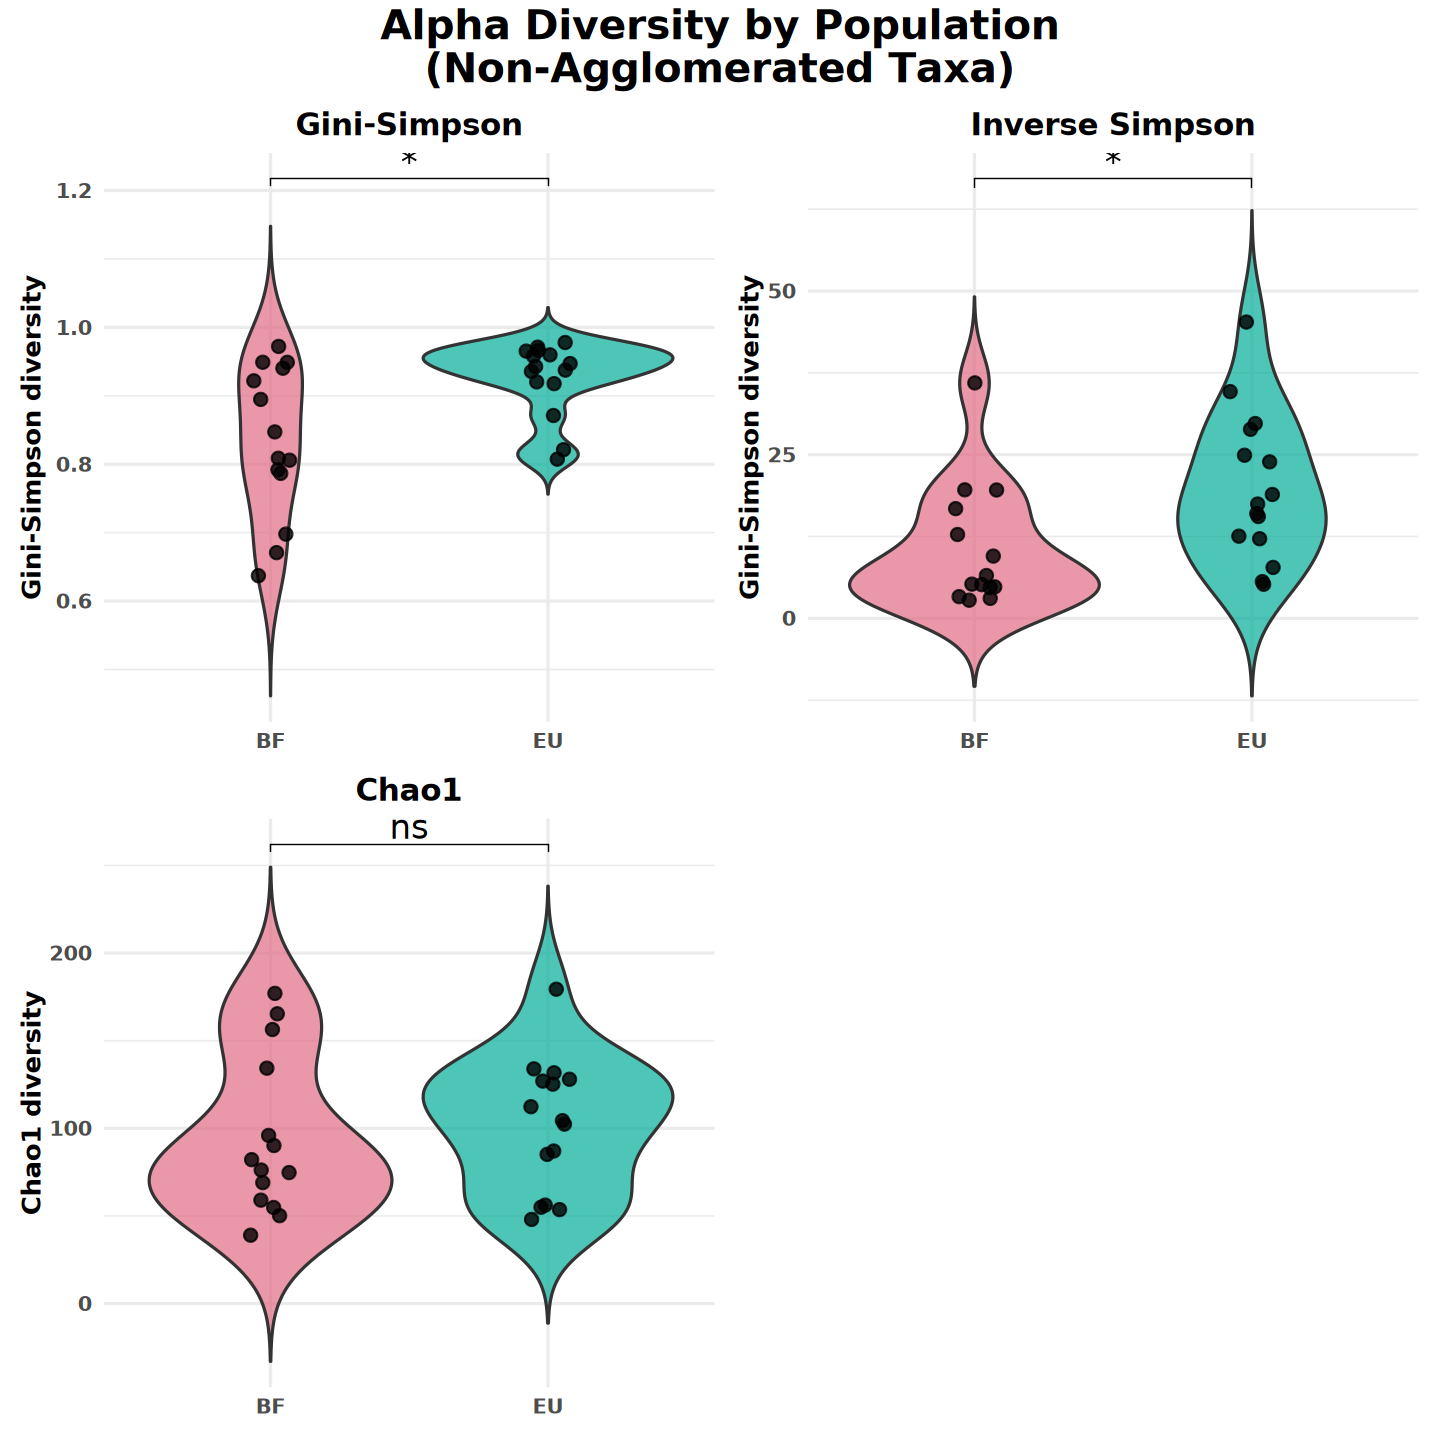

In [32]:
options(repr.plot.width = 12, repr.plot.height = 12)
alpha_combined_supp <-

    p_div_gini_simpson +
    p_div_inverse_simpson +
    p_div_chao1 +
    plot_layout(ncol = 2) +
    plot_annotation(
        title = "Alpha Diversity by Population\n(Non-Agglomerated Taxa)",
        theme = theme(
            plot.title = element_text(
                face = "bold",
                size = 24,
                hjust = 0.5
            )
        )
    )


alpha_combined_supp

In [33]:
alpha_div_df1 <- as.data.frame(colData(tse))



In [42]:
# save figure 
# main 
ggsave(
    filename = paste0(FIG_ALPHA_DIV_DIR, '/', PROJECT_NAME, '.alpha_diversity.main.png'),
    plot = alpha_combined,
    width = 12,
    height = 12,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_ALPHA_DIV_DIR, '/', PROJECT_NAME, '.alpha_diversity.main.pdf'),
    plot = alpha_combined,
    width = 12,
    height = 12,
    units = "in",
    bg = "white"
)
# main 
ggsave(
    filename = paste0(FIG_ALPHA_DIV_DIR, '/', PROJECT_NAME, '.alpha_diversity.supplement.png'),
    plot = alpha_combined_supp,
    width = 12,
    height = 12,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_ALPHA_DIV_DIR, '/', PROJECT_NAME, '.alpha_diversity.supplement.pdf'),
    plot = alpha_combined_supp,
    width = 12,
    height = 12,
    units = "in",
    bg = "white"
)


# save table for quarto plot
write_tsv( 
    alpha_div_df1,
    file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".alpha_diversity_for_plot.tsv")),
    quote = "needed"
)




### Find alpha diversity significance, effect sizes

In [35]:
alpha_df <- as.data.frame(colData(tse))

alpha_metrics <- c(
    "observed",
    "chao1",
    "shannon",
    "simpson",
    "gini_simpson",
    "inverse_simpson", 
    "faith"
    
)

alpha_stats <- map_dfr(alpha_metrics, function(metric1) {

    # Wilcoxon test
    test1 <- wilcox.test(
        alpha_df[[metric1]] ~ alpha_df$population_group,
        exact = FALSE
    )

    # medians by population
    medians1 <- alpha_df |>
        group_by(population_group) |>
        summarise(
            median = median(.data[[metric1]], na.rm = TRUE),
            .groups = "drop"
        )

    # rank-biserial effect size
    effect1 <- rstatix::wilcox_effsize(
        data = alpha_df,
        formula = as.formula(
            paste(metric1, "~ population_group")
        )
    )

    tibble(
        metric = metric1,

        BF_median = medians1$median[
            medians1$population_group == "BF"
        ],

        EU_median = medians1$median[
            medians1$population_group == "EU"
        ],

        effect_size = effect1$effsize,
        p_value = test1$p.value
    )
}) |>
    mutate(
        p_adj_BH = p.adjust(
            p_value,
            method = "BH"
        )
    )

alpha_stats

metric,BF_median,EU_median,effect_size,p_value,p_adj_BH
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
observed,79.0000000,104.0000000,0.11348968,0.5556375916,0.648243857
chao1,79.0000000,104.0000000,0.11348968,0.5556375916,0.648243857
shannon,2.6717124,3.6678994,0.34848959,0.0636173544,0.111330370
simpson,0.1017636,0.1840915,0.64835272,0.0005211089,0.003647763
gini_simpson,0.8279818,0.9427635,0.44574249,0.0173797008,0.040552635
inverse_simpson,5.8870134,17.4713785,0.44574249,0.0173797008,0.040552635
faith,8.3294975,7.7548526,0.06483527,0.7434206977,0.743420698


In [36]:
main_metrics <- c(
    "observed",
    "shannon",
    "simpson",
    "faith"
)

alpha_stats_main <- alpha_stats |>
    filter(metric %in% main_metrics) |>
    mutate(
        p_adj_BH = p.adjust(
            p_value,
            method = "BH"
        )
    )

alpha_stats_main

metric,BF_median,EU_median,effect_size,p_value,p_adj_BH
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
observed,79.0000000,104.0000000,0.11348968,0.5556375916,0.740850122
shannon,2.6717124,3.6678994,0.34848959,0.0636173544,0.127234709
simpson,0.1017636,0.1840915,0.64835272,0.0005211089,0.002084436
faith,8.3294975,7.7548526,0.06483527,0.7434206977,0.743420698


In [37]:
alpha_stats_display <- alpha_stats_main |>
    mutate(
        metric = recode(
            metric,
            observed = "Observed Richness",
            shannon  = "Shannon Diversity",
            simpson  = "Simpson Diversity",
            faith    = "Faith's PD"
        ),
        BF_median = round(BF_median, 3),
        EU_median = round(EU_median, 3),
        effect_size = round(effect_size, 3),
        p_value = signif(p_value, 3),
        p_adj_BH = signif(p_adj_BH, 3)
    ) |>
    rename(
        "Metric" = metric,
        "BF Median" = BF_median,
        "EU Median" = EU_median,
        "Effect Size (r)" = effect_size,
        "P-value" = p_value,
        "BH-adjusted P-value" = p_adj_BH
    )


In [38]:

# save table for quarto plot
write_tsv( 
    alpha_stats_display,
    file = file.path(REPORT_TABLE_DIR, paste0(PROJECT_NAME, ".alpha_diversity.stats.tsv")),
    quote = "needed"
)



### Save TSE for next notebook (beta diversity)

In [40]:
# save table for making figure in quarto report
saveRDS(tse, file = file.path(ALPHA_DIV_DIR, paste0(PROJECT_NAME, ".tse.withAlphaDiv.rds")))

# save table for making figure in quarto report
saveRDS(tse_genus, file = file.path(ALPHA_DIV_DIR, paste0(PROJECT_NAME, ".tse_genus.withAlphaDiv.rds")))


# save table for making figure in quarto report
saveRDS(tse_phylum, file = file.path(ALPHA_DIV_DIR, paste0(PROJECT_NAME, ".tse_phylum.withAlphaDiv.rds")))

